In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from klassen import City, distanz

In [2]:
df = pd.read_csv('msg_standorte_deutschland.csv')
#display (df)

In [3]:
#sns.set() 
#ax = sns.scatterplot(x="Breitengrad", y="Längengrad", data=df)

Die Daten aus der Tabelle (Pandas Datenframe) werden genutzt um für jede Stadt eine Klasse City zu erzeugen, die die Kooridinaten und die Nummer der Stadt enthält.

In [4]:
cities = []

df2 = df.iloc[:4]

for row in df2.itertuples():
    new = City(row.Breitengrad, row.Längengrad, row.Nummer, row.msg_Standort)
    cities.append(new)

# All Tours Algorithm
Es werden mittels Permutation alle möglichen Wege und deren Strecke berechnet. Anschließend wird der Weg mit der kleinsten Strecke ausgesucht. 
Dabei handelt es sich um einen Lösungsweg, der zwar definitiv die kürzeste Strecke ermitteln wird, aber sehr ineffizient und langsam ist, insbesondere für große Datensätze. 

# Überschreitet schon bei 21 Städten die Kapazitäten von Jupyter Lab! 

In [5]:
#Bei der Permutation wird die erste Stadt ausgelassen, da dort immer gestartet wird
permutation = list(itertools.permutations(cities[1:]))
alltours = []
#Vor und nach die Permutationen wird nun die Startstadt angefügt
for tour in permutation:
    alltours.append((cities[0],) + tour)
traveled = []

In [6]:
for tour in alltours:
    entfernung = 0
    for i in range (0, len(tour)-1):
        #wenn die letzte Stadt in der Liste erreicht ist, wird die Distanz zur Startstadt berechnet
        if i == len(tour)-1:
            entfernung += distanz(tour[i], tour[0])
        else:
            entfernung += distanz(tour[i], tour[i+1])
    traveled.append(entfernung)

In [8]:
print ("Die kürzeste Wegstrecke: " + str(min(traveled)))
for city in alltours[traveled.index(min(traveled))]:
    print ((city.nummer, city.name))

Die kürzeste Wegstrecke: 9.604064774444643
(1, 'Ismaning/München (Hauptsitz)')
(4, 'Bretten')
(3, 'Braunschweig')
(2, 'Berlin')


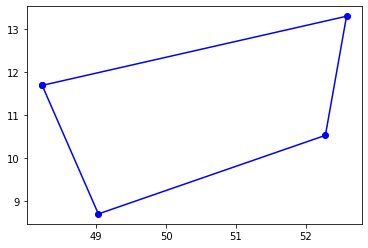

In [9]:
points = list(alltours[traveled.index(min(traveled))])
points.append(cities[0])
plt.plot([p.x for p in points], [p.y for p in points], "bo-")